# Gráficas Test 2 ($S_n$) + Comparativas $T_n$ vs $S_n$

Carga los CSV generados por `02_run_test2.ipynb` y genera todas las gráficas. Si además existe el CSV summary de $T_n$ (`tn_simulation_summary.csv`), genera las comparativas cruzadas.

Cambia `use_quick = True` si solo tienes los datos quick.

In [1]:
# --- Setup ---
import sys, os
from pathlib import Path

ROOT = Path.cwd().parent if (Path.cwd().name == 'notebooks') else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.plotting_sn import (
    plot_type_i_error_sn, plot_power_curves_sn, plot_runtime_sn,
    plot_q1_vs_q2, plot_weights_compare, plot_power_heatmap,
    plot_pvalue_distribution_h0_sn,
    plot_tn_vs_sn_power, plot_tn_vs_sn_runtime,
)

print(f'Working dir: {Path.cwd()}')

Working dir: C:\Users\tejon\PycharmProjects\Proyecto2EstadisticaNP


## Cargar CSVs

In [2]:
use_quick = False
suffix = '_quick' if use_quick else ''

raw_csv = ROOT / 'results' / 'data' / f'sn_simulation_raw{suffix}.csv'
sum_csv = ROOT / 'results' / 'data' / f'sn_simulation_summary{suffix}.csv'

if not raw_csv.exists():
    raise FileNotFoundError(
        f'No se encontró {raw_csv}. Ejecuta primero `02_run_test2.ipynb`.'
    )

df = pd.read_csv(raw_csv)
summary = pd.read_csv(sum_csv)
print(f'S_n: {raw_csv.name} ({len(df):,} filas) / {sum_csv.name} ({len(summary)} filas)')
print(f'q: {sorted(df.q.unique())}, pesos: {sorted(df.weight.unique())}')
print(f'n: {sorted(df.n.unique())}, estimadores: {sorted(df.estimator.unique())}')

# Carga T_n si existe para comparativas
tn_sum_csv = ROOT / 'results' / 'data' / 'tn_simulation_summary.csv'
summary_tn = None
if tn_sum_csv.exists():
    summary_tn = pd.read_csv(tn_sum_csv)
    print(f'\nT_n: {tn_sum_csv.name} ({len(summary_tn)} filas) — comparativas disponibles')
else:
    print(f'\n(no se encontró {tn_sum_csv.name} — saltando comparativas T_n vs S_n)')

S_n: sn_simulation_raw.csv (72,000 filas) / sn_simulation_summary.csv (360 filas)
q: [np.int64(1), np.int64(2)], pesos: ['gauss_0.5', 'gauss_1.0', 'laplace_1.0']
n: [np.int64(20), np.int64(40), np.int64(80), np.int64(160)], estimadores: ['argmin', 'median', 'trimmed']

T_n: tn_simulation_summary.csv (60 filas) — comparativas disponibles


## Resumen pivotado

In [3]:
print('Tasa de rechazo (argmin, q=2, columnas = peso):')
sub = summary[(summary['estimator']=='argmin') & (summary['q']==2)]
if not sub.empty:
    display(sub.pivot_table(index=['dist','n'], columns='weight', values='reject_rate').round(3))

print('\nTiempo medio por test (s), por estimador y q (promedio sobre pesos):')
display(summary.pivot_table(index=['estimator','n'], columns='q', values='mean_time_s').round(3))

Tasa de rechazo (argmin, q=2, columnas = peso):


weight                         gauss_0.5  gauss_1.0  laplace_1.0
dist                      n                                     
Cauchy(loc=2.0,scale=1.0) 20       0.015      0.015        0.005
                          40       0.040      0.035        0.020
                          80       0.045      0.040        0.015
                          160      0.025      0.050        0.035
Gamma(k=2.0,s=1.0)        20       0.155      0.200        0.170
                          40       0.650      0.465        0.400
                          80       0.980      0.840        0.570
                          160      1.000      0.975        0.855
Pareto(a=3.0,s=1.0)       20       0.270      0.220        0.300
                          40       0.340      0.550        0.875
                          80       0.575      0.950        1.000
                          160      0.960      1.000        1.000
Uniforme(1.0,3.0)         20       0.035      0.050        0.060
                          40       0.060      0.025        0.045
                          80       0.050      0.080        0.020
                          160      0.020      0.030        0.015
Weibull(k=1.5,s=1.0)      20       0.130      0.160        0.105
                          40       0.440      0.500        0.410
                          80       0.845      0.880        0.805
                          160      1.000      1.000        0.965


Tiempo medio por test (s), por estimador y q (promedio sobre pesos):


q                   1      2
estimator n                 
argmin    20    2.692  1.334
          40    3.992  1.892
          80    6.745  3.140
          160  12.293  5.700
median    20    0.144  0.144
          40    0.203  0.200
          80    0.340  0.332
          160   0.586  0.587
trimmed   20    0.302  0.299
          40    0.371  0.381
          80    0.508  0.505
          160   0.795  0.793

In [4]:
fig_dir = ROOT / 'results' / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
alpha = 0.05

def show(path):
    if path is not None and Path(path).exists():
        display(Image(filename=str(path)))
    else:
        print('(sin imagen)')

def show_many(paths):
    for p in paths:
        show(p)

### Error Tipo I bajo H₀ (una figura por (q, w))

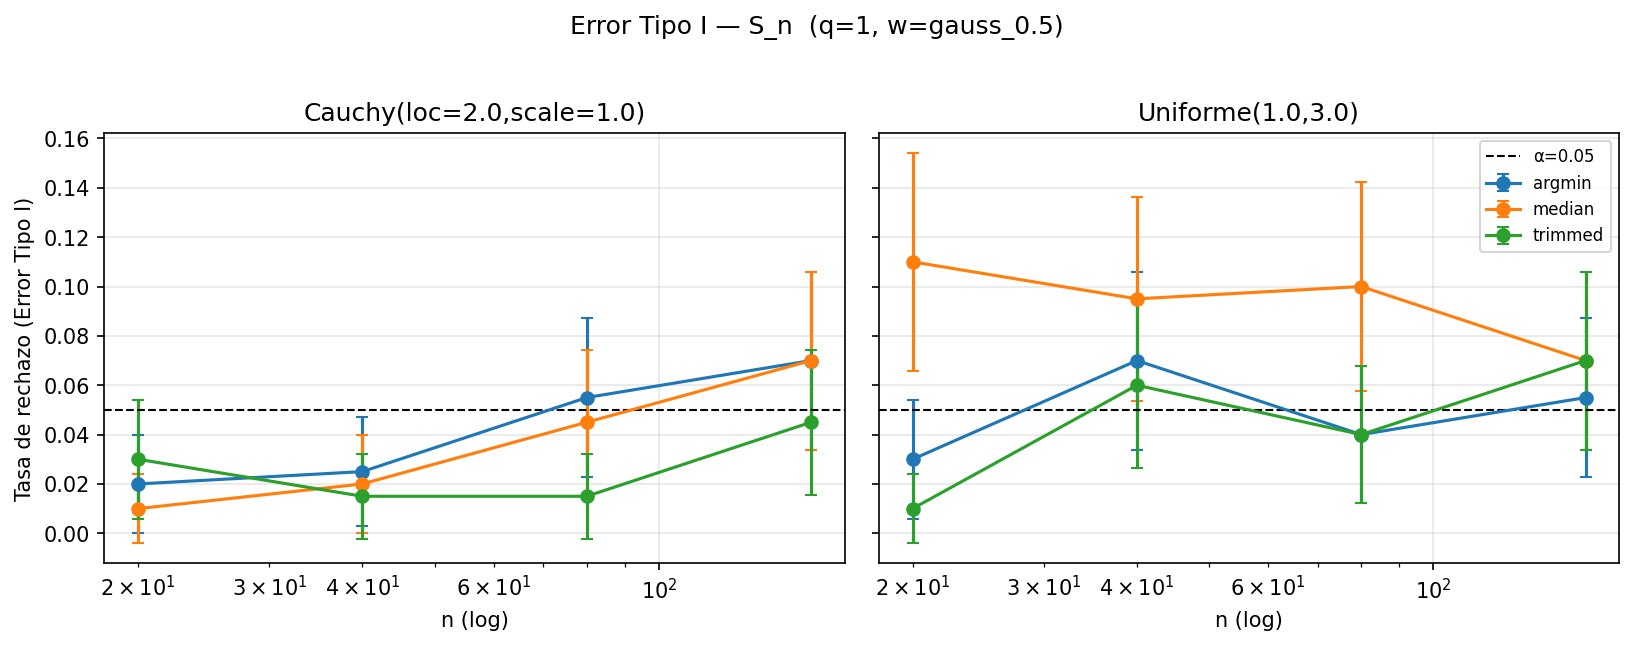

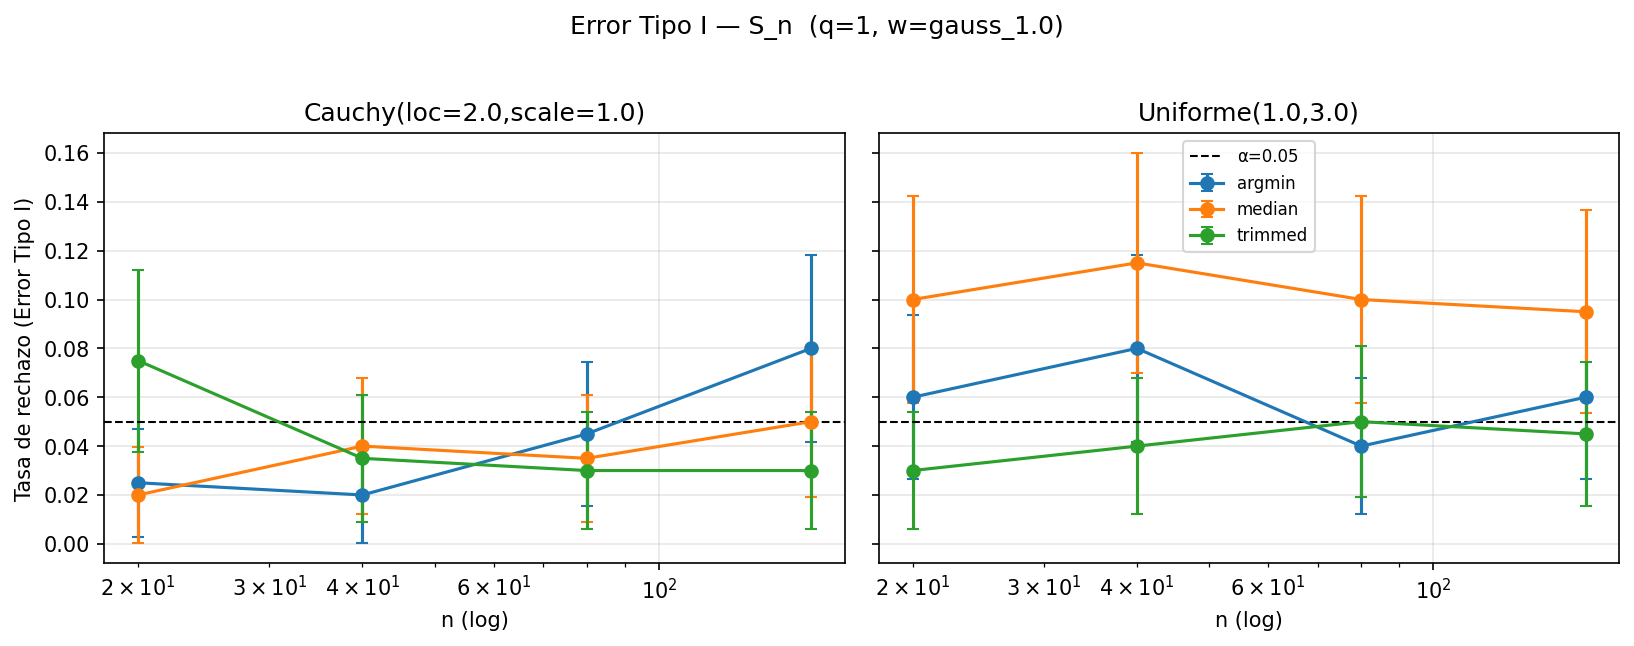

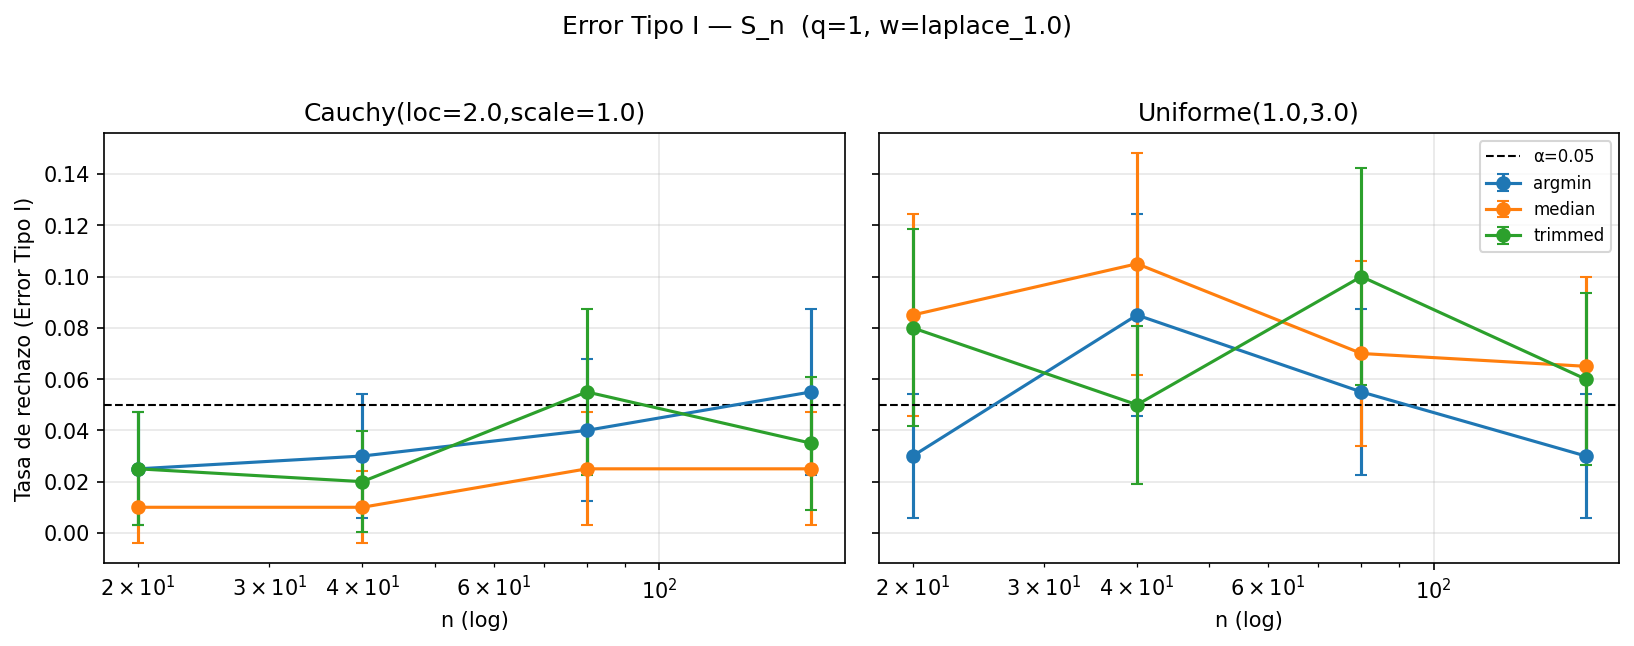

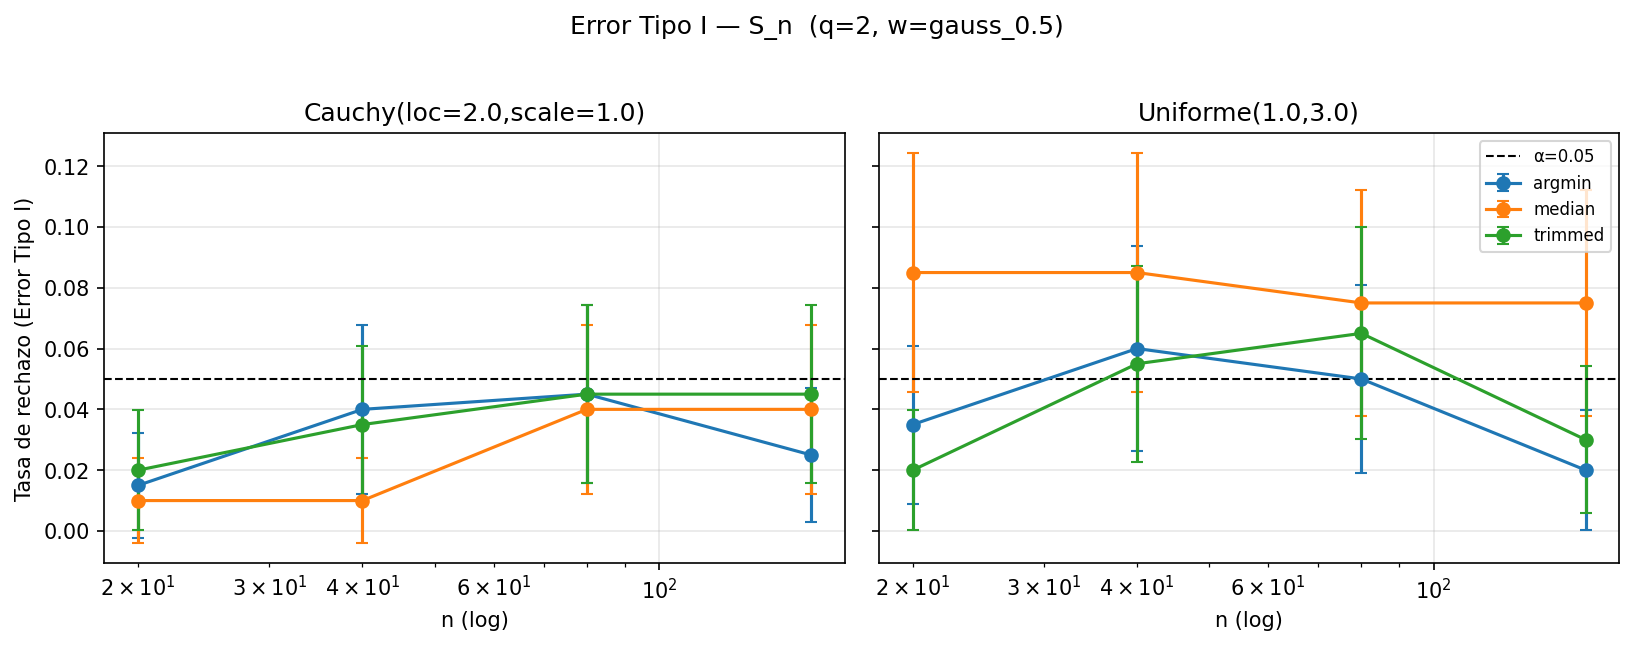

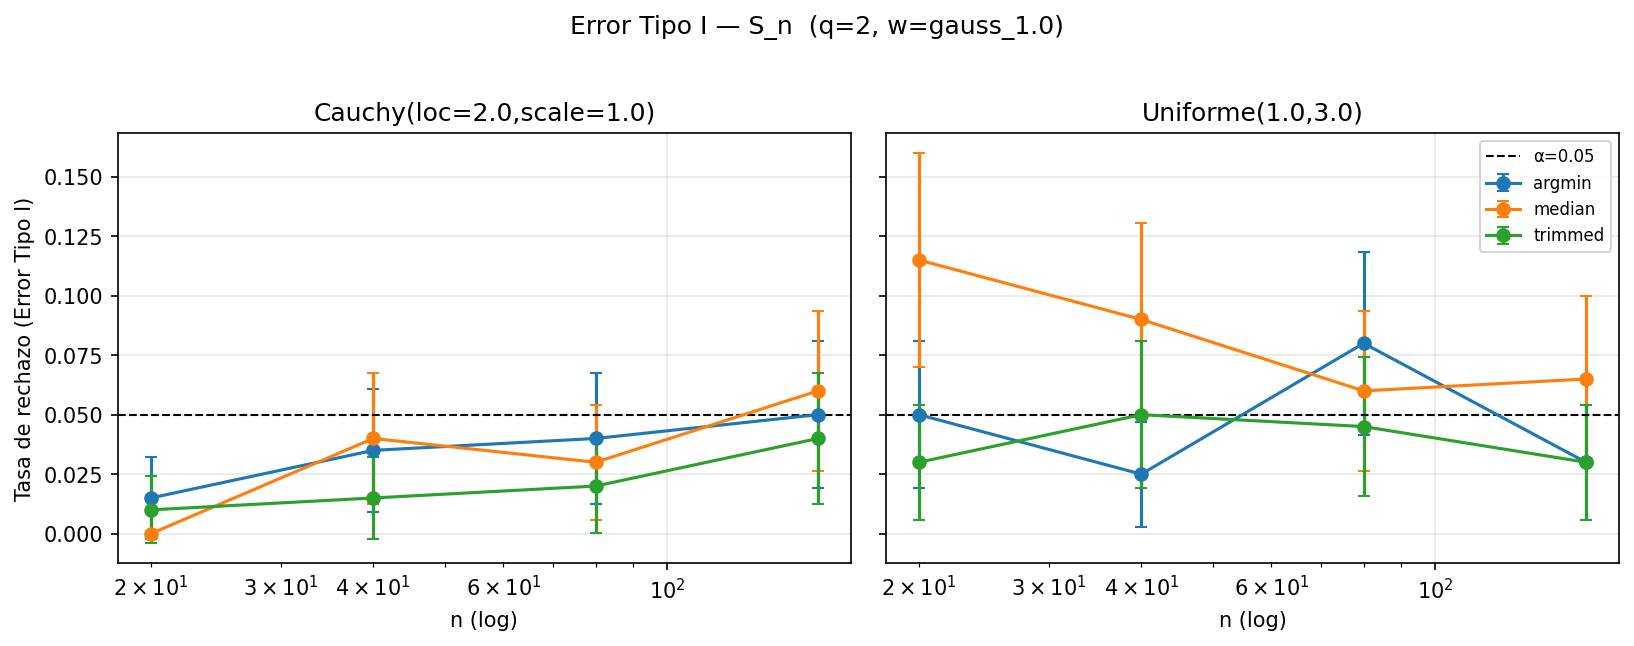

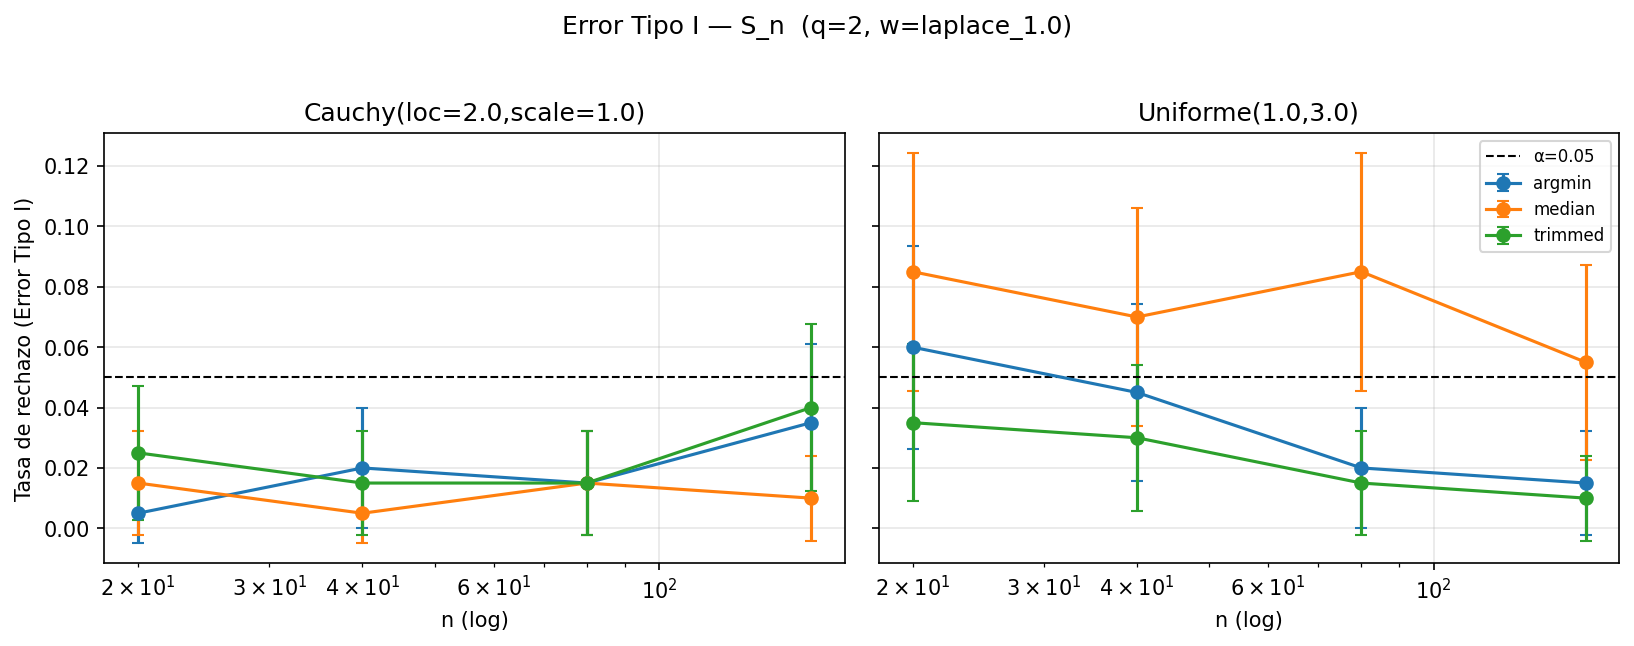

In [5]:
show_many(plot_type_i_error_sn(summary, alpha=alpha, outdir=fig_dir))

### Curvas de potencia bajo Hₐ (una figura por (q, w))

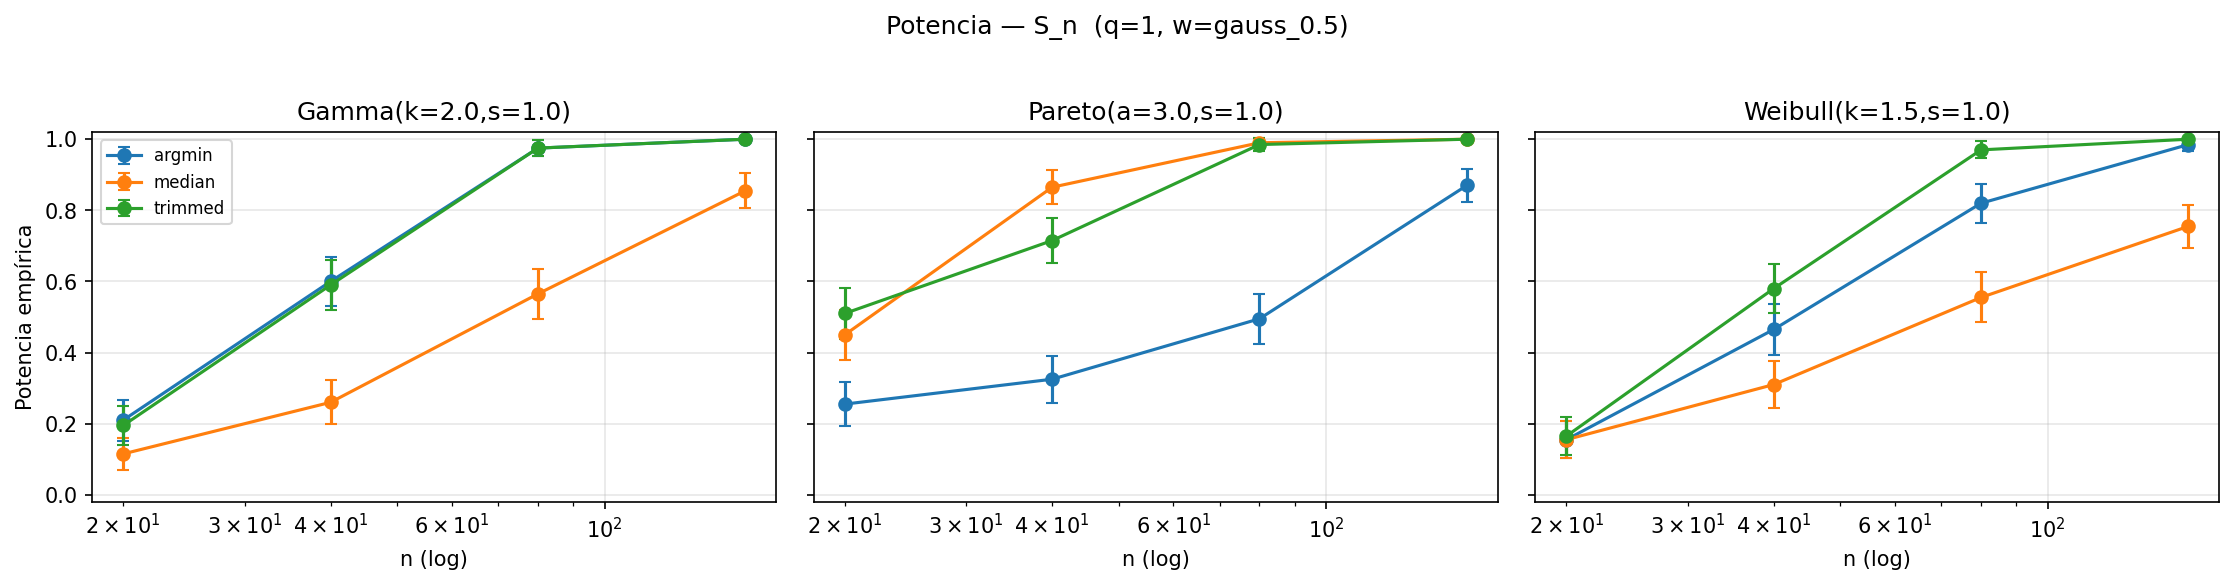

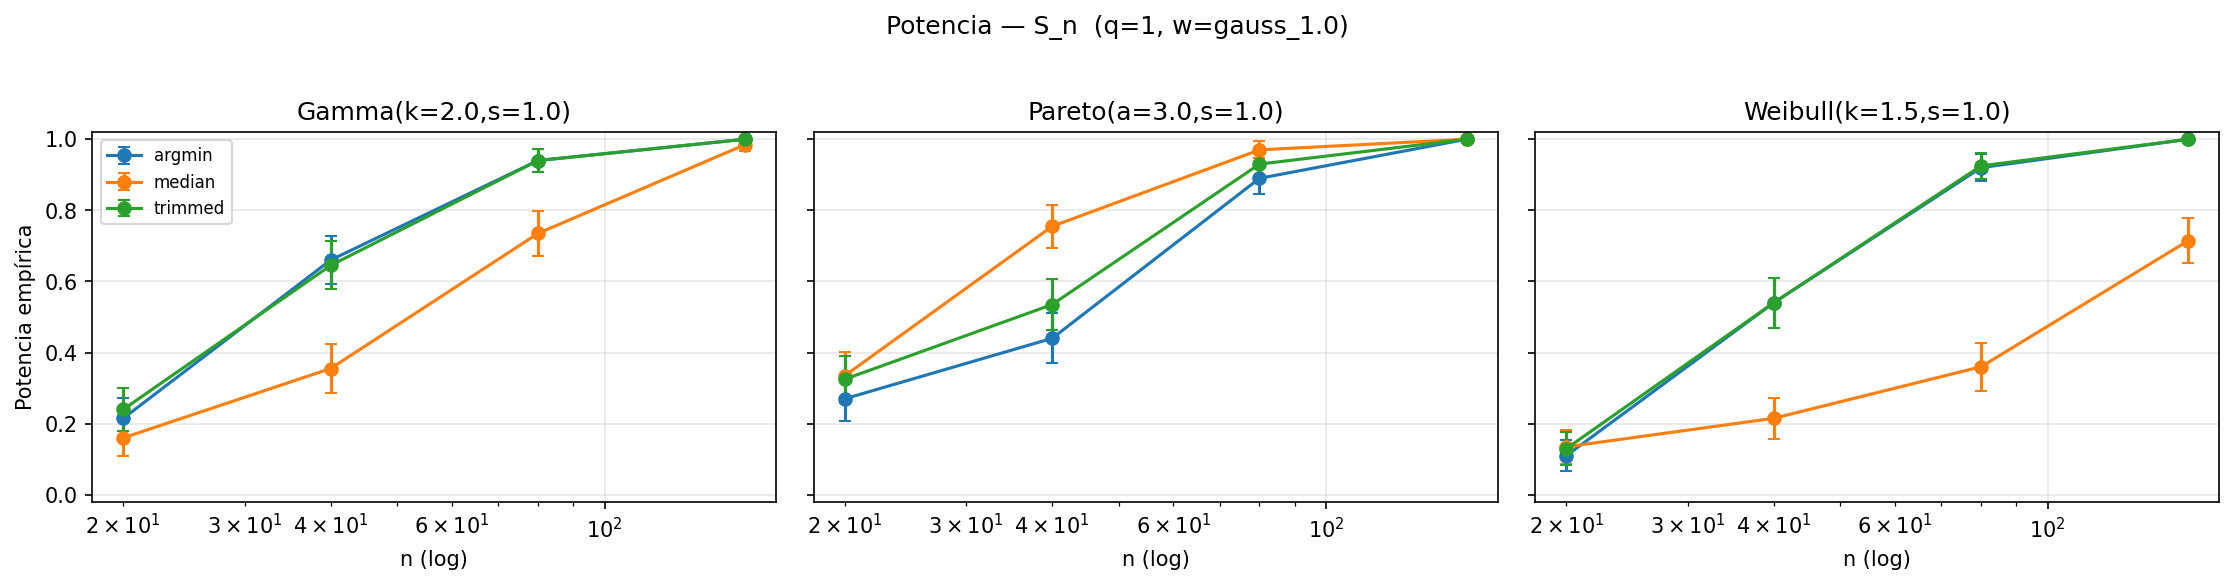

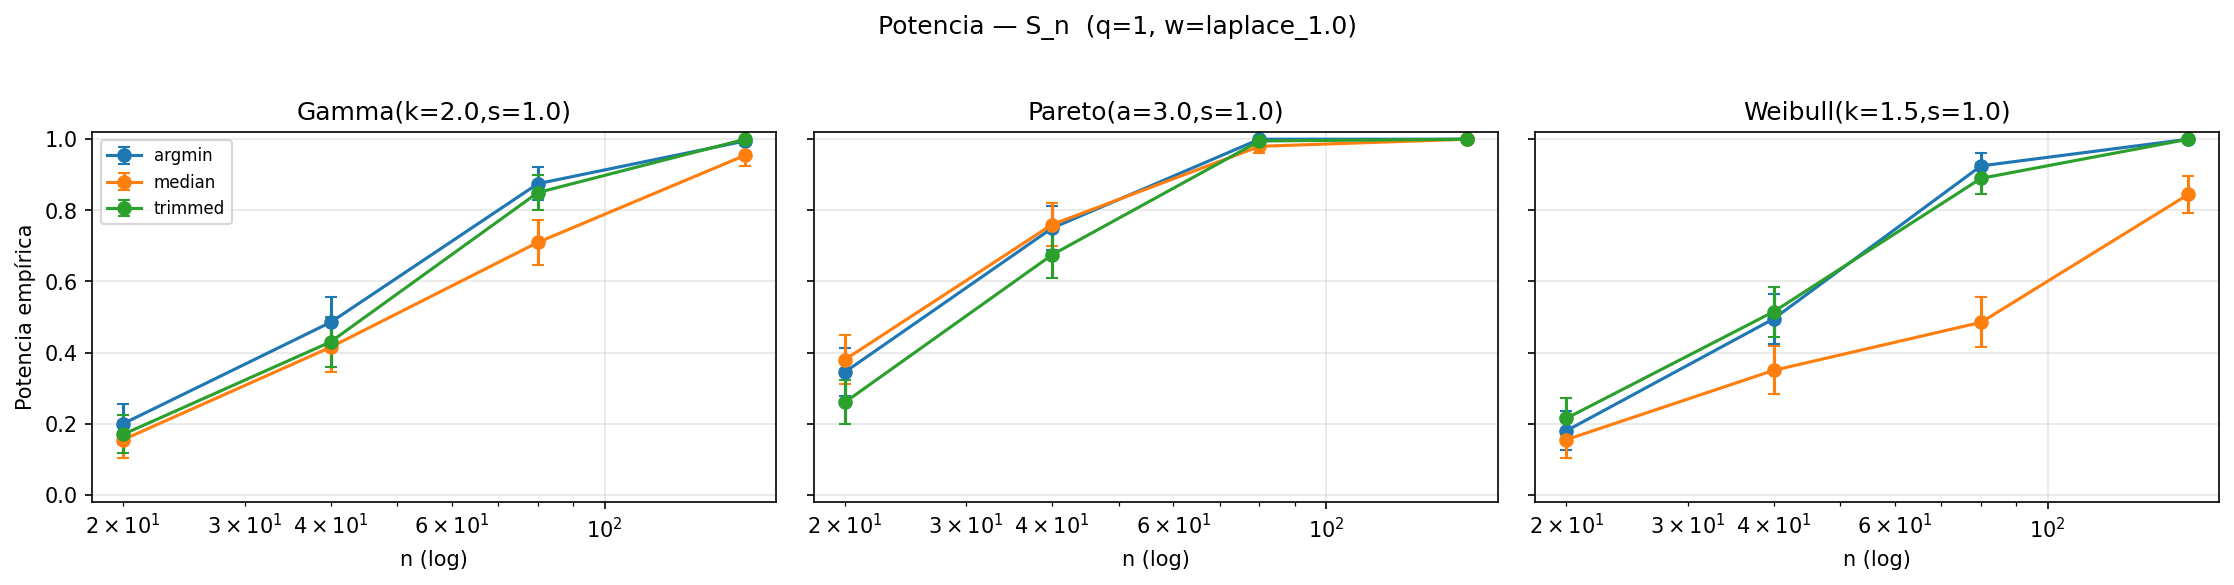

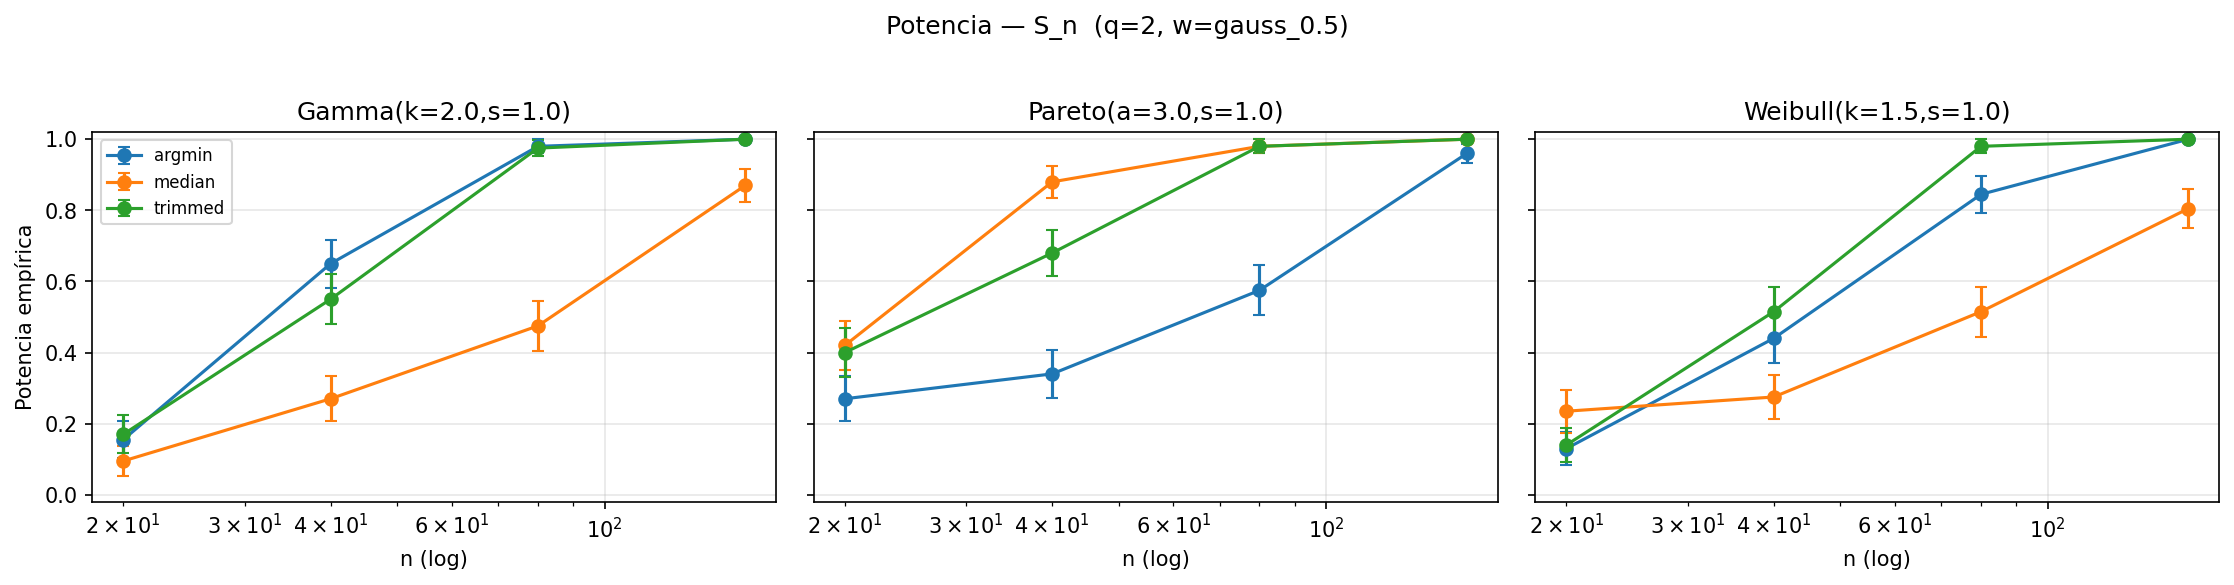

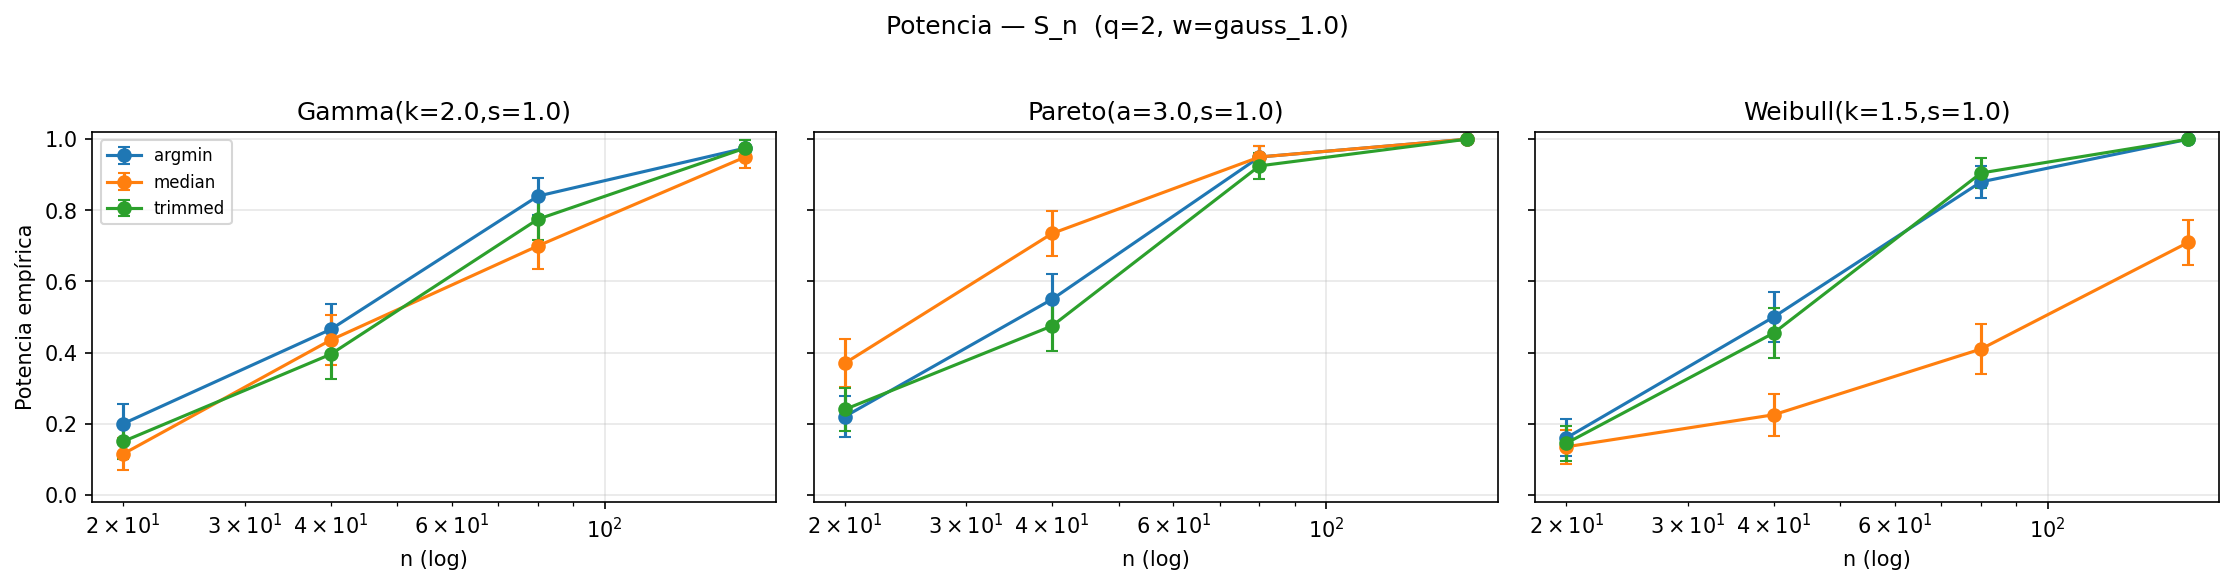

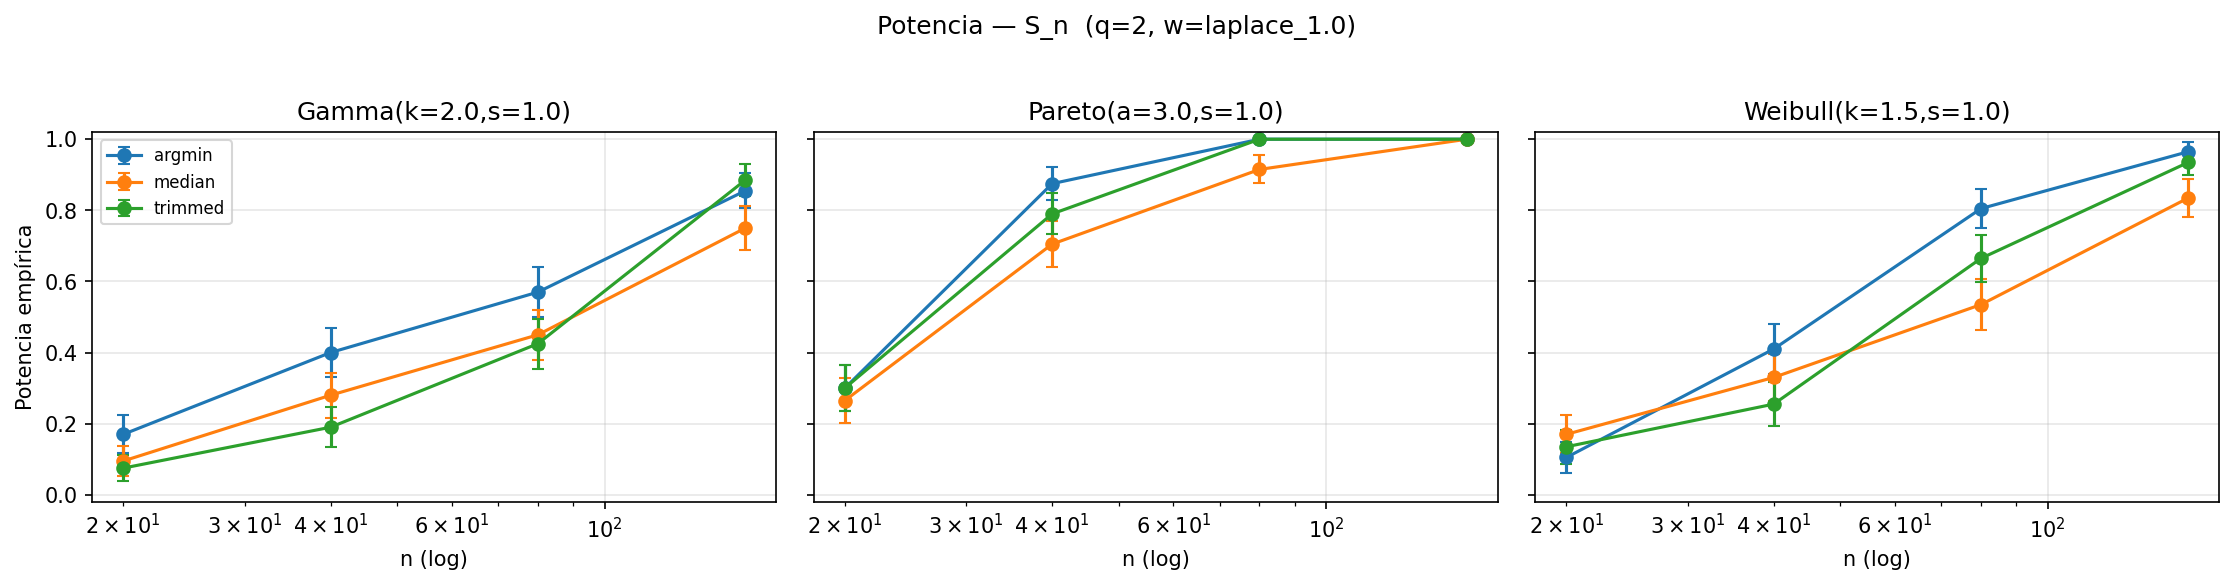

In [6]:
show_many(plot_power_curves_sn(summary, outdir=fig_dir))

### Comparación q=1 vs q=2

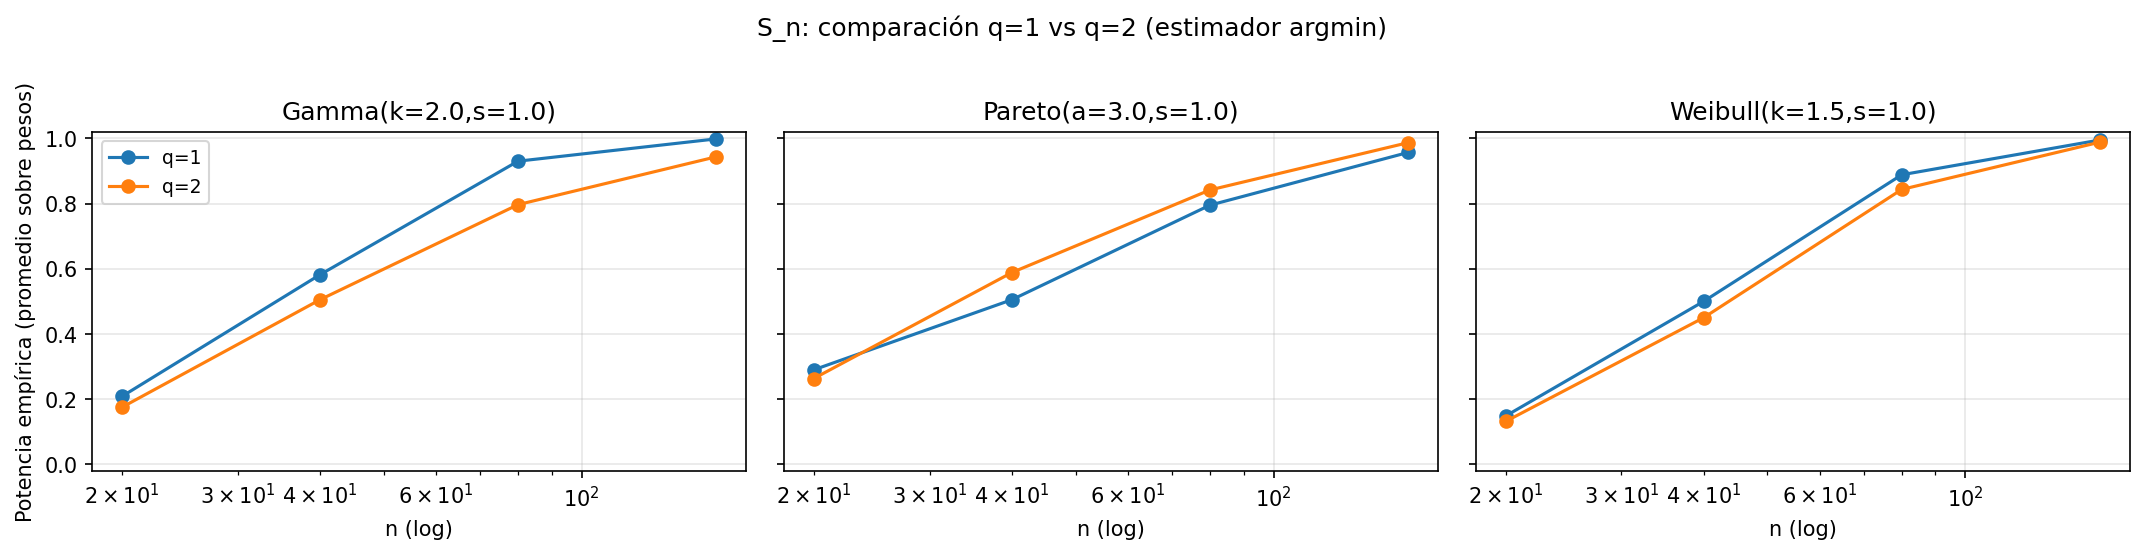

In [7]:
show(plot_q1_vs_q2(summary, outdir=fig_dir))

### Comparación entre funciones de peso w(t)

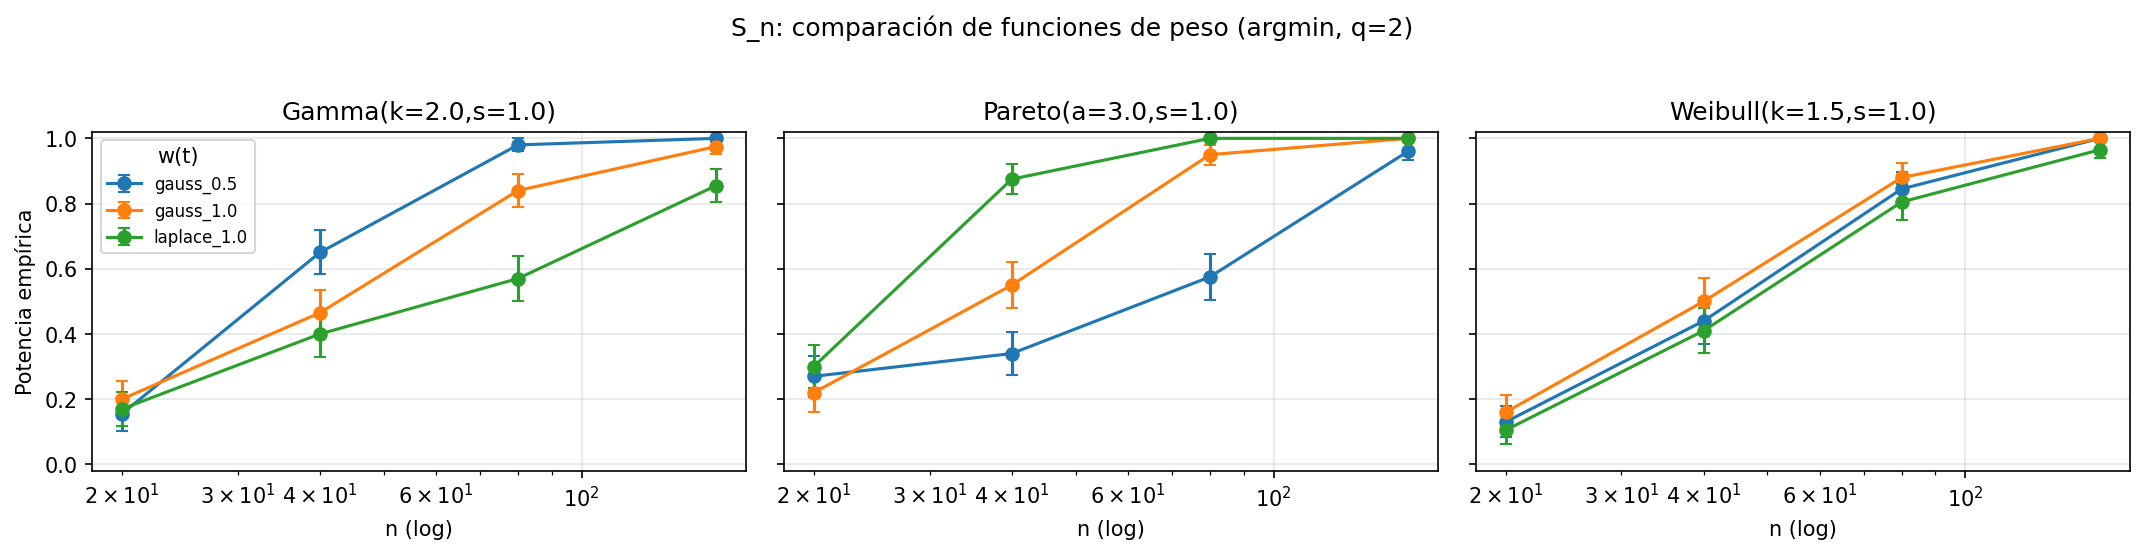

In [8]:
show(plot_weights_compare(summary, outdir=fig_dir))

### Heatmap de potencia (estimador argmin)

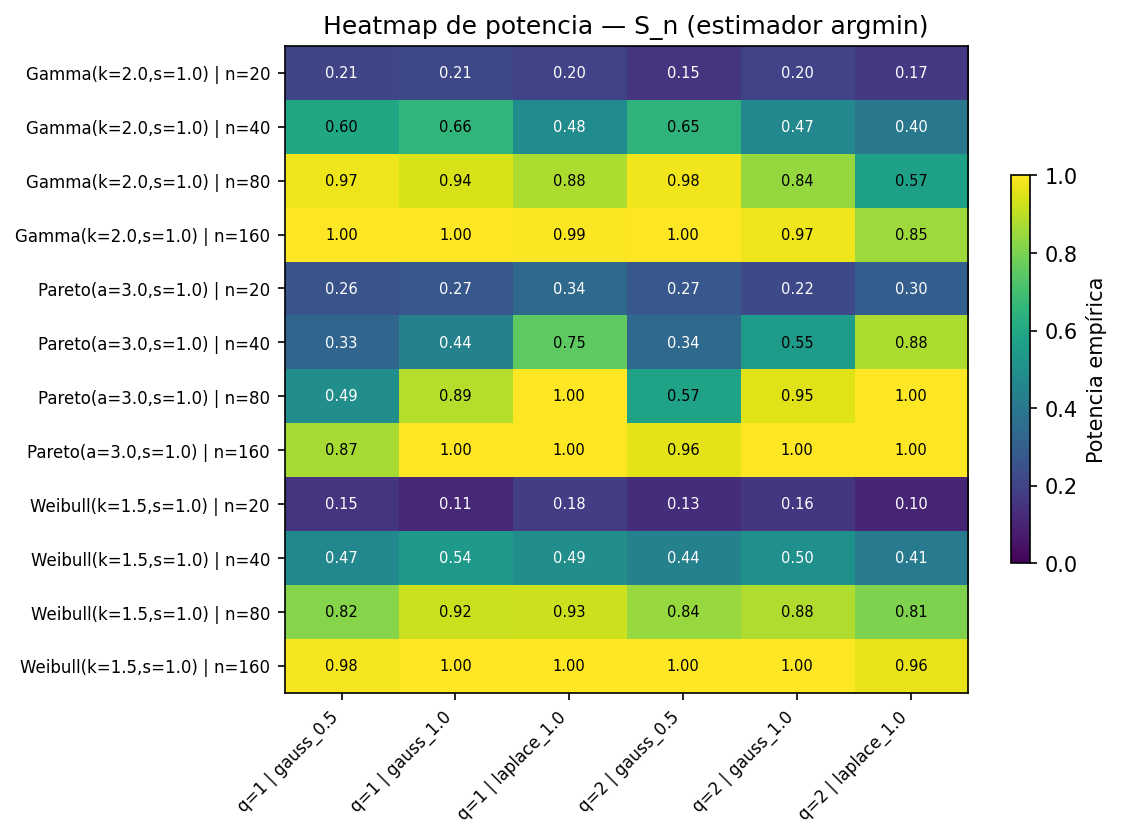

In [9]:
show(plot_power_heatmap(summary, outdir=fig_dir))

### Tiempo de ejecución vs n

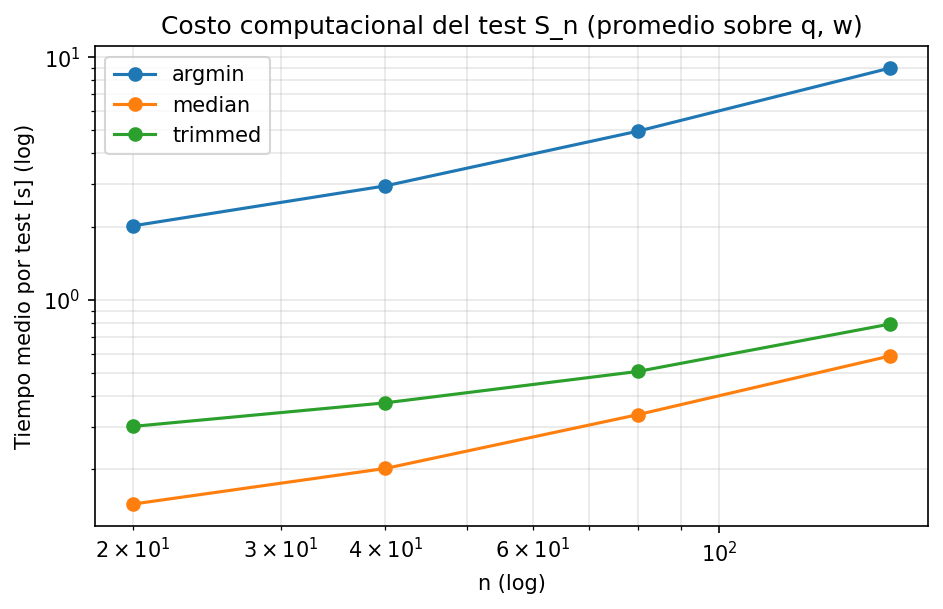

In [10]:
show(plot_runtime_sn(summary, outdir=fig_dir))

### Distribución del p-valor bajo H₀

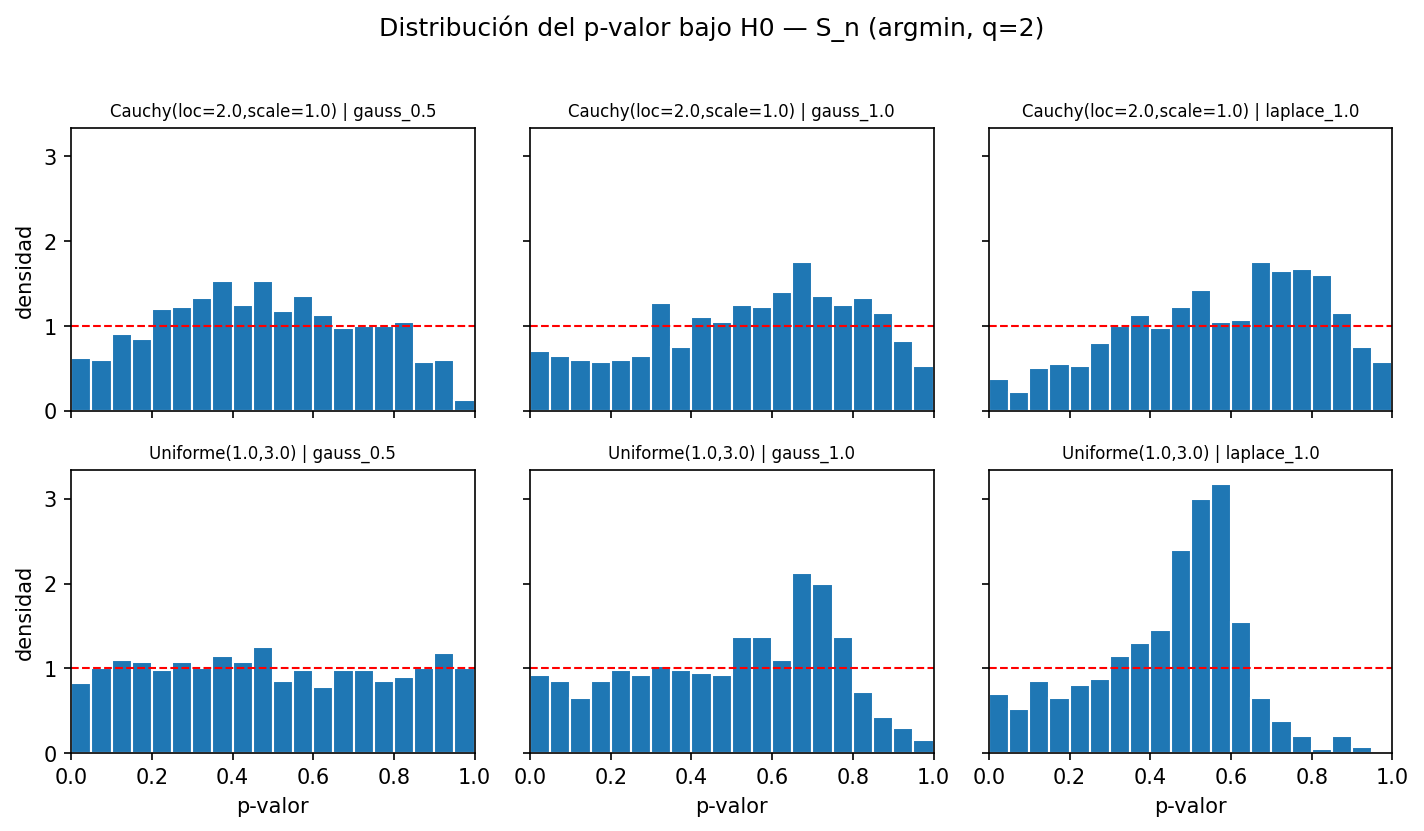

In [11]:
show(plot_pvalue_distribution_h0_sn(df, outdir=fig_dir))

## Comparativas T_n vs S_n

Solo si `tn_simulation_summary.csv` existe.

Potencia:


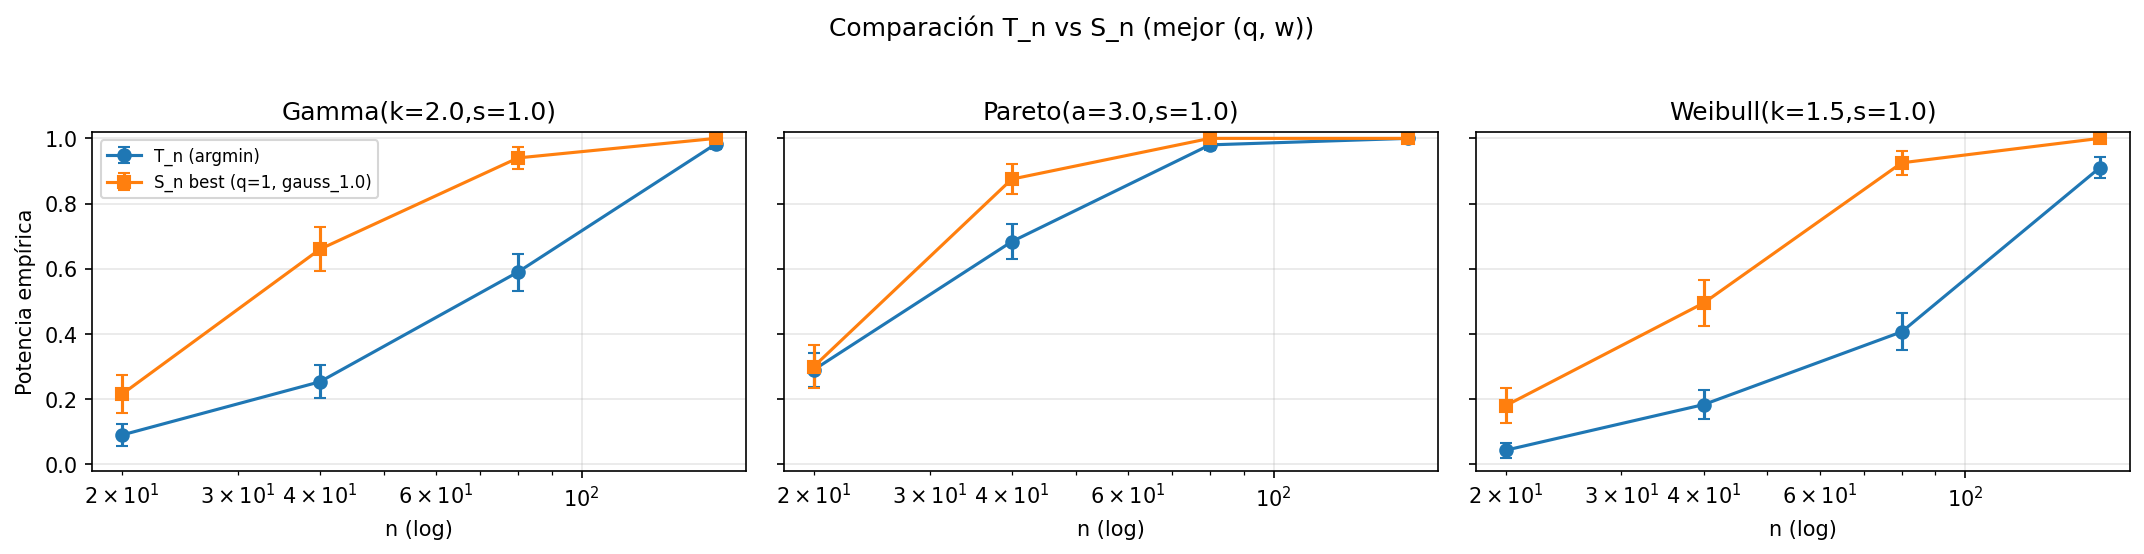

Runtime:


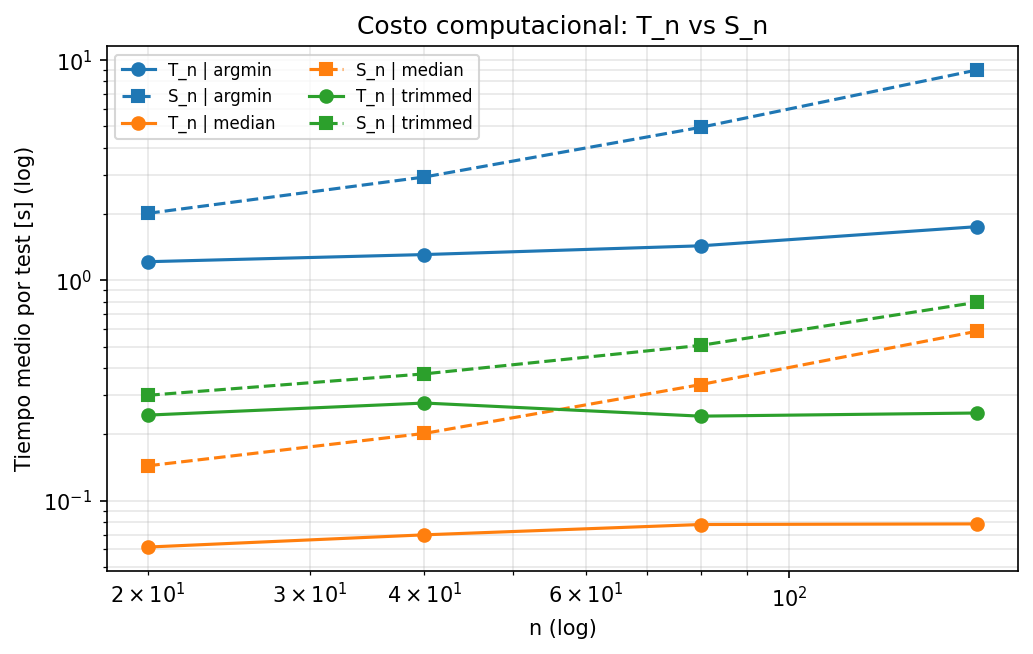

In [12]:
if summary_tn is not None:
    print('Potencia:')
    show(plot_tn_vs_sn_power(summary_tn, summary, outdir=fig_dir))
    print('Runtime:')
    show(plot_tn_vs_sn_runtime(summary_tn, summary, outdir=fig_dir))
else:
    print('No hay datos de T_n para comparar. Ejecuta primero el Test 1.')

## Exploración interactiva

Plantilla para hacer cortes propios.

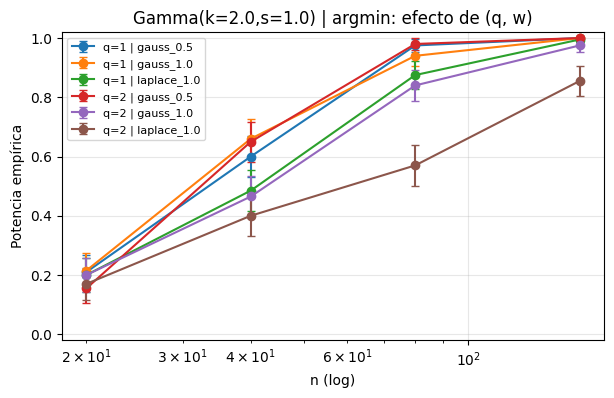

In [13]:
# Ejemplo: para una distribución dada, comparar todas las (q, w) combinations
dist = 'Gamma(k=2.0,s=1.0)'
est = 'argmin'

sub = summary[(summary['dist']==dist) & (summary['estimator']==est)].copy()
sub['config'] = 'q=' + sub['q'].astype(str) + ' | ' + sub['weight']

fig, ax = plt.subplots(figsize=(7,4))
for cfg in sorted(sub['config'].unique()):
    s2 = sub[sub['config']==cfg].sort_values('n')
    ax.errorbar(s2['n'], s2['reject_rate'], yerr=2*s2['se_rate'],
                marker='o', capsize=3, label=cfg)
ax.set_xscale('log')
ax.set_xlabel('n (log)')
ax.set_ylabel('Potencia empírica')
ax.set_title(f'{dist} | {est}: efecto de (q, w)')
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.show()